# 1. Base de datos

Este capítulo cubre la sección 1 del entregable: problema de investigación, justificación,
fuente y licencia, diccionario de variables, estructura, tamaño de la muestra, calidad de los
datos y consideraciones éticas.

In [1]:
import sys
import warnings

sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import utils as u

u.estilo()
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
np.random.seed(u.SEMILLA)

## 1.1 Problema de investigación

La tesis doctoral en la que se inscribe este proyecto propone una arquitectura de gobernanza
para la gestión de proyectos de logística inteligente orientada a la resiliencia alimentaria
en territorios PDET y ZOMAC. Uno de sus componentes es un modelo analítico que anticipe
riesgos de desabastecimiento. Este proyecto construye la primera pieza empírica de ese
componente.

**Pregunta.** Con la información disponible al cierre de una semana, ¿es posible anticipar si un
corredor de abastecimiento (municipio de origen → central mayorista) sufrirá una
**interrupción** la semana siguiente?

**Definición operativa de la variable objetivo.** Para cada corredor *c* y semana *t*:

$$
\text{interrupcion}_{c,t+1} = \mathbb{1}\left[\, r_{c,t+1} < 0{,}5 \cdot \bar r_{c,t-7:t} \,\right]
$$

donde $r_{c,t}$ son los kilogramos que llegan por el corredor en la semana *t* divididos entre los
días en que el DANE encuestó esa central en esa semana, y $\bar r_{c,t-7:t}$ es el promedio de las
ocho semanas anteriores (incluida *t*). Normalizar por días de encuesta evita confundir una
semana con menos días de recolección con una caída real del abastecimiento.

**Población en riesgo.** Solo se consideran corredores regulares: los que registraron
abastecimiento en al menos 4 de las 8 semanas previas y cuya central fue encuestada en *t+1*.

**Tipo de problema.** Clasificación binaria sobre un panel espacio-temporal (corredores ×
semanas, con coordenadas de origen y destino). Según la figura 1 del enunciado se sigue la
**ruta A** (clasificación) añadiendo las secciones 2.6 a 2.8 (componentes temporal, espacial y
espacio-temporal) y una partición cronológica.

## 1.2 Justificación de la selección del dataset

* **Pertinencia temática.** SIPSA-A registra cada carga de alimentos que ingresa a las
  principales centrales mayoristas del país, con su municipio de procedencia. Es la fuente
  oficial más detallada sobre flujos logísticos de alimentos en Colombia y permite observar
  directamente la continuidad del abastecimiento, que es el núcleo de la resiliencia
  alimentaria en la propuesta doctoral.
* **Articulación territorial.** Incluye la central de Bazurto (Cartagena), de interés para la
  Secretaría de Agroindustria de Bolívar, y cientos de municipios de origen, de los cuales una
  parte son PDET. El cruce con el listado oficial de municipios PDET permite analizar si los
  corredores que nacen en esos territorios son más frágiles.
* **Dificultad adecuada.** La interrupción de un corredor depende de factores no observados
  (clima, orden público, precios, decisiones de transportadores), por lo que el problema no es
  trivial y deja espacio para los modelos del resto del curso.

## 1.3 Fuente y licencia

| Recurso | Entidad | Enlace | Uso |
|---|---|---|---|
| SIPSA-A, microdatos 2018-2025 (18 archivos) | DANE | [microdatos.dane.gov.co, catálogo 697](https://microdatos.dane.gov.co/index.php/catalog/697) · [datos.gov.co ymnp-apvk](https://www.datos.gov.co/d/ymnp-apvk) | Registros de ingreso de alimentos |
| Municipios PDET | Agencia de Renovación del Territorio | [datos.gov.co idrk-ba8y](https://www.datos.gov.co/d/idrk-ba8y) | Marca PDET del municipio de origen |
| DIVIPOLA, códigos y coordenadas de municipios | DANE | [datos.gov.co gdxc-w37w](https://www.datos.gov.co/d/gdxc-w37w) | Centroides (EPSG:4326) |
| Geometrías municipales simplificadas | IGAC / gestores catastrales | [datos.gov.co bhcx-bx97](https://www.datos.gov.co/d/bhcx-bx97) | Mapa base y coropletas |

**Licencia.** Los cuatro recursos se publican como datos abiertos en el Portal de Datos
Abiertos del Estado colombiano; su reutilización es libre con atribución a la entidad que los
produce. Los microdatos del DANE son anonimizados y de acceso público. El archivo del primer
cuatrimestre de 2026 figura en el catálogo pero el servidor del DANE respondía
`RESOURCE_NOT_AVAILABLE` al momento de la descarga (29/09/2026), por lo que el periodo de
estudio termina en diciembre de 2025.

El script `src/01_descarga_consolidacion.py` descarga y consolida los archivos;
`src/02_construir_panel.py` construye el panel semanal. Ambos son reproducibles de principio a fin.

## 1.4 Datos crudos: un registro por carga

In [2]:
env = pd.read_parquet(u.INTERIM / "sipsa_a_envios.parquet")
print(f"Registros: {len(env):,}   Columnas: {env.shape[1]}")
env.head()

Registros: 15,493,054   Columnas: 10


,mercado,fecha,cod_depto,cod_mpio,depto_origen,mpio_origen,grupo,alimento,kg,periodo
0,"Armenia, Mercar",2018-01-02,52,52838,NARIÑO,TÚQUERRES,"TUBERCULOS, RAICES Y PLATANOS",Papa suprema,"9,750.000",2018-S1
1,"Armenia, Mercar",2018-01-02,52,52838,NARIÑO,TÚQUERRES,"TUBERCULOS, RAICES Y PLATANOS",Papa capira,"5,000.000",2018-S1
2,"Armenia, Mercar",2018-01-02,52,52838,NARIÑO,TÚQUERRES,"TUBERCULOS, RAICES Y PLATANOS",Papa suprema,"28,000.000",2018-S1
3,"Armenia, Mercar",2018-01-02,52,52317,NARIÑO,GUACHUCAL,"TUBERCULOS, RAICES Y PLATANOS",Papa suprema,"9,750.000",2018-S1
4,"Armenia, Mercar",2018-01-02,66,66001,RISARALDA,PEREIRA,VERDURAS Y HORTALIZAS,Cebolla junca,"1,400.000",2018-S1


In [3]:
dicc_crudo = pd.DataFrame([
    ("mercado", "categórica", "-", "Central mayorista donde se registra el ingreso (ciudad, mercado)"),
    ("fecha", "fecha", "día", "Día de la encuesta en la central"),
    ("cod_depto", "categórica", "código DIVIPOLA", "Departamento de procedencia de la carga"),
    ("cod_mpio", "categórica", "código DIVIPOLA / ISO", "Municipio de procedencia (o país, para importaciones)"),
    ("depto_origen", "categórica", "-", "Nombre del departamento de procedencia"),
    ("mpio_origen", "categórica", "-", "Nombre del municipio o país de procedencia"),
    ("grupo", "categórica", "-", "Grupo de alimentos SIPSA (8 grupos)"),
    ("alimento", "categórica", "-", "Producto específico"),
    ("kg", "numérica continua", "kilogramos", "Cantidad que ingresa en la carga"),
    ("periodo", "categórica", "-", "Archivo de origen (semestre o cuatrimestre)"),
], columns=["variable", "tipo", "unidad", "significado"])
dicc_crudo

,variable,tipo,unidad,significado
0,mercado,categórica,-,Central mayorista donde se registra el ingreso...
1,fecha,fecha,día,Día de la encuesta en la central
2,cod_depto,categórica,código DIVIPOLA,Departamento de procedencia de la carga
3,cod_mpio,categórica,código DIVIPOLA / ISO,"Municipio de procedencia (o país, para importa..."
4,depto_origen,categórica,-,Nombre del departamento de procedencia
5,mpio_origen,categórica,-,Nombre del municipio o país de procedencia
6,grupo,categórica,-,Grupo de alimentos SIPSA (8 grupos)
7,alimento,categórica,-,Producto específico
8,kg,numérica continua,kilogramos,Cantidad que ingresa en la carga
9,periodo,categórica,-,Archivo de origen (semestre o cuatrimestre)


## 1.5 Diccionario del panel de modelado

El panel agrega las cargas por corredor y semana. Todas las predictoras se calculan con
información disponible al cierre de la semana *t*; la variable objetivo describe *t+1*.

In [4]:
panel = u.cargar_panel()
dicc = pd.DataFrame([
    ("mercado", "categórica (32)", "-", "Central mayorista de destino", "identificación / predictora"),
    ("cod_mpio", "categórica (925)", "DIVIPOLA", "Municipio de origen", "identificador (no se usa como predictora)"),
    ("semana", "fecha", "semana (lunes)", "Semana t de referencia", "índice temporal"),
    ("semana_t1", "fecha", "semana (lunes)", "Semana t+1 que se predice", "índice temporal"),
    ("interrupcion_t1", "binaria", "0/1", "Caída > 50 % del abastecimiento en t+1 frente al promedio de 8 semanas", "OBJETIVO"),
    ("tasa_t1", "numérica", "kg/día", "Abastecimiento en t+1", "EXCLUIDA (define el objetivo)"),
    ("tasa_t", "numérica", "kg/día", "Abastecimiento en t", "auxiliar"),
    ("base8", "numérica", "kg/día", "Promedio de las 8 semanas previas", "auxiliar"),
    ("log_base8", "numérica", "log(1 + t/día)", "Escala del corredor", "predictora"),
    ("ratio_t", "numérica", "razón", "Abastecimiento de t sobre su promedio de 8 semanas", "predictora"),
    ("ratio_t_1", "numérica", "razón", "Abastecimiento de t-1 sobre su promedio de 8 semanas", "predictora"),
    ("cv8", "numérica", "razón", "Coeficiente de variación en 8 semanas", "predictora"),
    ("pend8_rel", "numérica", "1/semana", "Pendiente de la tendencia de 8 semanas, relativa al promedio", "predictora"),
    ("activas8", "numérica discreta", "semanas", "Semanas con abastecimiento entre las 8 previas", "predictora"),
    ("activas26", "numérica", "proporción", "Fracción de semanas activas en las 26 previas", "predictora"),
    ("n_envios8", "numérica", "cargas/semana", "Promedio de cargas semanales en 8 semanas", "predictora"),
    ("n_alimentos8", "numérica", "productos/semana", "Promedio de productos distintos por semana", "predictora"),
    ("antig_sem", "numérica discreta", "semanas", "Semanas desde la primera aparición del corredor", "predictora"),
    ("sh_<grupo>", "numérica (8)", "proporción", "Participación de cada grupo de alimentos en 8 semanas", "predictoras"),
    ("grupo_dom", "categórica (8)", "-", "Grupo de alimentos dominante del corredor", "predictora"),
    ("frac_caida_mercado_t", "numérica", "proporción", "Fracción de corredores de la misma central con caída en t", "predictora"),
    ("frac_caida_nacional_t", "numérica", "proporción", "Fracción de corredores del país con caída en t", "predictora"),
    ("dist_km", "numérica", "km", "Distancia haversine entre centroides de origen y ciudad de la central", "predictora"),
    ("mismo_depto", "binaria", "0/1", "Origen y central en el mismo departamento", "predictora"),
    ("local", "binaria", "0/1", "Origen es el mismo municipio de la central", "predictora"),
    ("pdet_origen", "binaria", "0/1", "Municipio de origen PDET", "predictora"),
    ("depto_origen", "categórica (32)", "-", "Departamento de origen", "predictora"),
    ("festivos_t1", "numérica discreta", "días", "Festivos nacionales en la semana t+1 (calendario conocido)", "predictora"),
    ("sem_sin, sem_cos", "numérica", "-", "Codificación cíclica de la semana del año de t+1", "predictoras"),
    ("lat_o, lon_o, lat_m, lon_m", "numérica", "grados (EPSG:4326)", "Coordenadas de origen y destino", "EDA espacial / bloques"),
], columns=["variable", "tipo", "unidad", "significado", "rol"])
dicc

,variable,tipo,unidad,significado,rol
0,mercado,categórica (32),-,Central mayorista de destino,identificación / predictora
1,cod_mpio,categórica (925),DIVIPOLA,Municipio de origen,identificador (no se usa como predictora)
2,semana,fecha,semana (lunes),Semana t de referencia,índice temporal
3,semana_t1,fecha,semana (lunes),Semana t+1 que se predice,índice temporal
4,interrupcion_t1,binaria,0/1,Caída > 50 % del abastecimiento en t+1 frente ...,OBJETIVO
5,tasa_t1,numérica,kg/día,Abastecimiento en t+1,EXCLUIDA (define el objetivo)
6,tasa_t,numérica,kg/día,Abastecimiento en t,auxiliar
7,base8,numérica,kg/día,Promedio de las 8 semanas previas,auxiliar
8,log_base8,numérica,log(1 + t/día),Escala del corredor,predictora
9,ratio_t,numérica,razón,Abastecimiento de t sobre su promedio de 8 sem...,predictora


## 1.6 Estructura de los datos

* **Unidad de observación del dato crudo:** una carga (vehículo o lote) que ingresa a una
  central mayorista en un día, con su producto, cantidad y municipio de procedencia.
* **Unidad de observación del modelo:** corredor-semana, es decir, el par
  (central de destino, municipio de origen) en una semana.
* **Nivel de agregación:** semanal (lunes a domingo), sumando todas las cargas del corredor.
* **Tipo de datos:** panel longitudinal espacio-temporal. Cada corredor es una serie de tiempo
  semanal y tiene dos localizaciones (origen y destino).

In [5]:
n_corr = panel.groupby(["mercado", "cod_mpio"]).ngroups
p_pred = len(u.NUMERICAS) + len(u.BINARIAS) + len(u.CATEGORICAS)
p_dummies = len(u.NUMERICAS) + len(u.BINARIAS) + sum(panel[c].nunique() for c in u.CATEGORICAS)
resumen = pd.Series({
    "Registros crudos (cargas)": len(env),
    "Observaciones del panel (corredor-semana)": len(panel),
    "Predictoras (antes de codificar)": p_pred,
    "Columnas tras one-hot (máximo)": p_dummies,
    "Relación n/p (con one-hot)": len(panel) / p_dummies,
    "Corredores (entidades)": n_corr,
    "Municipios de origen": panel["cod_mpio"].nunique(),
    "Centrales mayoristas": panel["mercado"].nunique(),
    "Semanas": panel["semana"].nunique(),
    "Casos clase 1 (interrupción)": int(panel[u.VAR_OBJETIVO].sum()),
    "Casos clase 0": int((1 - panel[u.VAR_OBJETIVO]).sum()),
})
resumen.to_frame("valor").style.format("{:,.0f}")

,valor
Registros crudos (cargas),"15,493,054"
Observaciones del panel (corredor-semana),"744,921"
Predictoras (antes de codificar),30
Columnas tras one-hot (máximo),97
Relación n/p (con one-hot),"7,680"
Corredores (entidades),"4,512"
Municipios de origen,925
Centrales mayoristas,32
Semanas,414
Casos clase 1 (interrupción),"208,115"


**Tamaño efectivo.** Las 744 mil filas no son independientes: provienen de 4.512 corredores
observados a lo largo del tiempo y de 925 municipios de origen. Las filas de un mismo corredor
están autocorrelacionadas (sección 2.6) y los corredores vecinos se parecen (sección 2.7). El
tamaño efectivo está entre el número de corredores y el número de filas; por eso la validación
y los intervalos de confianza se construyen por bloques (semanas completas) y no por filas.

## 1.7 Calidad de los datos

### 1.7.1 Valores faltantes

El dato crudo no tiene celdas vacías en las columnas informativas después de eliminar
226.633 filas vacías (líneas con solo separadores al final de algunos CSV). El faltante
relevante es **estructural**: semanas en que una central no fue encuestada. En esas semanas el
abastecimiento es desconocido, no cero. La matriz siguiente muestra la cobertura
central × semana.

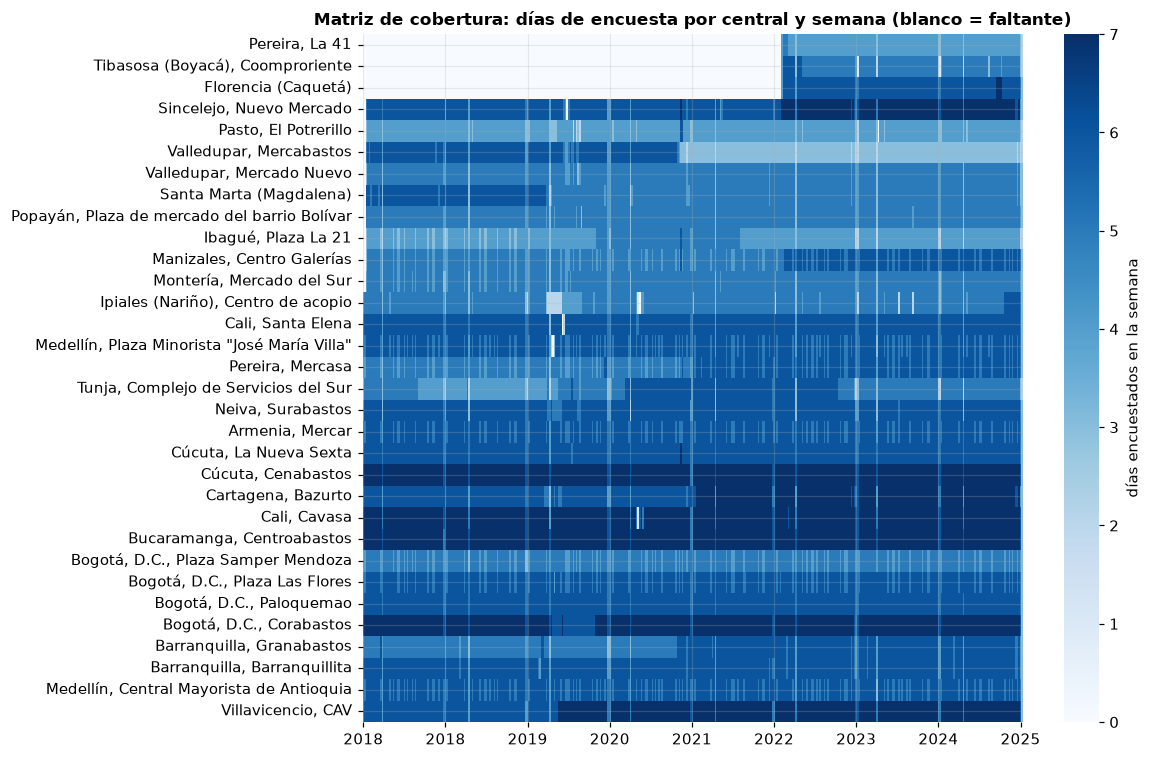

In [6]:
env["semana"] = env["fecha"].dt.to_period("W-SUN").dt.start_time
env["mercado_n"] = env["mercado"].astype(str).replace(
    {"Cali, Santa Helena": "Cali, Santa Elena", "Pereira, La 41-Impala": "Pereira, La 41"})
cob = env.groupby(["mercado_n", "semana"])["fecha"].nunique().unstack(fill_value=0)
cob = cob.reindex(columns=pd.date_range(cob.columns.min(), cob.columns.max(), freq="W-MON"), fill_value=0)
cob = cob.loc[(cob > 0).mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(cob, cmap="Blues", cbar_kws={"label": "días encuestados en la semana"}, ax=ax,
            xticklabels=52, yticklabels=True)
ax.set_xticklabels([pd.Timestamp(c).strftime("%Y") for c in cob.columns[::52]], rotation=0)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Matriz de cobertura: días de encuesta por central y semana (blanco = faltante)")
plt.tight_layout()
plt.show()

In [7]:
falt = (cob == 0).mean(axis=1).sort_values(ascending=False)
print("Proporción de semanas sin encuesta por central (las 10 mayores):")
print(falt.head(10).round(3).to_string())
print(f"\nPromedio global de semanas sin encuesta: {(cob == 0).to_numpy().mean():.3f}")

Proporción de semanas sin encuesta por central (las 10 mayores):
mercado_n
Pereira, La 41                                 0.634
Florencia (Caquetá)                            0.634
Tibasosa (Boyacá), Coomproriente               0.634
Sincelejo, Nuevo Mercado                       0.007
Pasto, El Potrerillo                           0.007
Popayán, Plaza de mercado del barrio Bolívar   0.005
Manizales, Centro Galerías                     0.005
Ibagué, Plaza La 21                            0.005
Montería, Mercado del Sur                      0.005
Santa Marta (Magdalena)                        0.005

Promedio global de semanas sin encuesta: 0.061


**Mecanismo.** Para decidir entre MCAR, MAR y MNAR se compara el abastecimiento previo de las
semanas seguidas de un hueco de encuesta con el de las semanas seguidas de dato. Si el faltante
fuera MNAR (se deja de encuestar porque llega poca carga), las semanas previas a un hueco
tendrían niveles de abastecimiento más bajos. El análisis se restringe al periodo en que cada
central está en operación.

In [8]:
from scipy import stats

sem = pd.date_range(cob.columns.min(), cob.columns.max(), freq="W-MON")
flag = []
for m in cob.index:
    serie = cob.loc[m]
    activa = serie[serie > 0]
    if activa.empty:
        continue
    rango = serie.loc[activa.index.min():activa.index.max()]
    siguiente_falta = (rango.shift(-1) == 0)
    flag.append(pd.DataFrame({"mercado": m, "semana": rango.index, "falta_t1": siguiente_falta.values,
                              "dias_t": rango.values}))
flag = pd.concat(flag)
kg_sem = env.groupby(["mercado_n", "semana"])["kg"].sum().rename("kg").reset_index() \
            .rename(columns={"mercado_n": "mercado"})
flag = flag.merge(kg_sem, on=["mercado", "semana"], how="left")
flag = flag[flag["dias_t"] > 0]
flag["kg_dia"] = flag["kg"] / flag["dias_t"]
flag["kg_dia_rel"] = flag["kg_dia"] / flag.groupby("mercado")["kg_dia"].transform("median")

a = flag.loc[flag["falta_t1"], "kg_dia_rel"].dropna()
b = flag.loc[~flag["falta_t1"], "kg_dia_rel"].dropna()
mw = stats.mannwhitneyu(a, b)
rbc = 1 - 2 * mw.statistic / (len(a) * len(b))
print(f"Semanas seguidas de faltante: {len(a):,}; seguidas de dato: {len(b):,}")
print(f"Mediana del abastecimiento relativo en t: con faltante en t+1 = {a.median():.3f}; sin faltante = {b.median():.3f}")
print(f"Mann-Whitney U p = {mw.pvalue:.3g}; correlación biserial de rangos = {rbc:.3f}")
mes = flag.assign(mes=flag["semana"].dt.month).groupby("mes")["falta_t1"].mean()
print("\nProporción de semanas seguidas de faltante, por mes:")
print(mes.round(3).to_string())

Semanas seguidas de faltante: 5; seguidas de dato: 12,553
Mediana del abastecimiento relativo en t: con faltante en t+1 = 0.937; sin faltante = 1.000
Mann-Whitney U p = 0.174; correlación biserial de rangos = 0.351

Proporción de semanas seguidas de faltante, por mes:
mes
1    0.000
2    0.000
3    0.001
4    0.001
5    0.002
6    0.001
7    0.000
8    0.000
9    0.000
10   0.000
11   0.000
12   0.000


**Interpretación.** El faltante tiene dos orígenes distintos:

1. **Incorporación tardía de centrales** (Pereira-La 41, Florencia y Tibasosa, con 63 % de
   semanas sin dato). Antes de su entrada al operativo la central no existe en la muestra; el
   faltante depende solo de la central y del periodo, que son observables, es decir, es **MAR
   por diseño**. No se imputa: los corredores de esas centrales empiezan a contar cuando la
   central empieza a reportar (el panel arranca en la primera semana observada de cada corredor).
2. **Huecos internos**: solo 5 semanas-central en ocho años. Con tan pocos casos la prueba de
   Mann-Whitney no tiene potencia (p = 0,17) y la diferencia de medianas es pequeña (0,94 frente a
   1,00), por lo que no hay evidencia de un mecanismo MNAR. Estas semanas se tratan como
   ausentes (NaN), nunca como cero, y quedan fuera de la población en riesgo cuando la semana
   *t+1* no tiene encuesta.

La prueba de Little no es aplicable aquí porque el faltante no está en columnas de una tabla
rectangular sino en celdas central-semana completas. Dentro del panel de modelado, la única
variable con faltantes es `ratio_t_1` (192 filas, 0,03 %), cuando la semana *t-1* no tuvo
encuesta; se imputa con la mediana de entrenamiento dentro del pipeline.

### 1.7.2 Duplicados exactos y casi-duplicados

In [9]:
cols_clave = ["mercado", "fecha", "cod_mpio", "alimento", "kg"]
dup_exact = env.duplicated(subset=cols_clave, keep=False)
dup_casi = env.duplicated(subset=["mercado", "fecha", "cod_mpio", "alimento"], keep=False)
print(f"Registros en grupos de duplicados exactos: {dup_exact.sum():,} ({dup_exact.mean():.2%})")
print(f"Registros en grupos casi-duplicados (misma central, día, origen y producto; kg distinto o igual): "
      f"{dup_casi.sum():,} ({dup_casi.mean():.2%})")
tam = env[dup_exact].groupby(cols_clave, observed=True).size()
print("\nTamaño de los grupos de duplicados exactos:")
print(tam.value_counts().sort_index().head(8).to_string())
print("\nkg más frecuentes entre duplicados exactos:")
print(env.loc[dup_exact, "kg"].value_counts().head(8).to_string())

Registros en grupos de duplicados exactos: 4,034,531 (26.04%)
Registros en grupos casi-duplicados (misma central, día, origen y producto; kg distinto o igual): 10,966,161 (70.78%)



Tamaño de los grupos de duplicados exactos:
2    1107392
3     276334
4      98423
5      41594
6      19665
7      10172
8       5757
9       3444

kg más frecuentes entre duplicados exactos:
kg
1,000.000     350170
10,000.000    221705
6,000.000     211451
2,000.000     202054
500.000       189074
5,000.000     178630
1,500.000     138931
200.000       111500


**Interpretación.** Una cuarta parte de los registros tiene un gemelo exacto. No son errores de
captura: SIPSA-A registra cada vehículo que ingresa y las cargas se despachan en tamaños
estándar (1.000, 2.000, 5.000 o 10.000 kg). Dos camiones de papa de 10 toneladas desde Túquerres
a Armenia el mismo día generan dos filas idénticas legítimas. Los valores más frecuentes entre
los duplicados son precisamente esos tamaños redondos. Como el registro no trae un identificador
de vehículo, no es posible separar duplicados legítimos de dobles digitaciones; eliminarlos
subestimaría el abastecimiento en cerca de 26 %. **Decisión:** conservarlos y trabajar con
agregados semanales, donde una eventual doble digitación aislada tiene poco peso.

### 1.7.3 Valores imposibles o inconsistentes

In [10]:
divi = pd.read_csv(u.RAW / "divipola_municipios.csv", dtype=str)
cod_validos = set(divi["cod_mpio"].str.zfill(5))
es_nacional = env["cod_mpio"].astype(str).isin(cod_validos)
checks = pd.Series({
    "kg <= 0": int((env["kg"] <= 0).sum()),
    "kg no numérico": int(env["kg"].isna().sum()),
    "fecha inválida": int(env["fecha"].isna().sum()),
    "fecha fuera de 2018-2025": int(((env["fecha"] < "2018-01-01") | (env["fecha"] > "2025-12-31")).sum()),
    "origen no DIVIPOLA (importación o 'n.a.')": int((~es_nacional).sum()),
    "kg > 40.000 (más que un tractocamión)": int((env["kg"] > 40000).sum()),
})
checks.to_frame("registros")

,registros
kg <= 0,1
kg no numérico,2
fecha inválida,2
fecha fuera de 2018-2025,0
origen no DIVIPOLA (importación o 'n.a.'),202248
kg > 40.000 (más que un tractocamión),37


In [11]:
print("Nombres de central con variantes de escritura:")
for m in sorted(env["mercado"].astype(str).unique()):
    if "Santa" in m and "Cali" in m or "La 41" in m:
        print("  ", m, f"{(env['mercado'] == m).sum():,}")
print("\nOrígenes no nacionales más frecuentes:")
print(env.loc[~es_nacional, "mpio_origen"].astype(str).value_counts().head(8).to_string())
print(f"\nParticipación de importaciones en kg: {env.loc[~es_nacional, 'kg'].sum() / env['kg'].sum():.2%}")

Nombres de central con variantes de escritura:


   Cali, Santa Elena 297,115
   Cali, Santa Helena 211,341
   Pereira, La 41 40,984
   Pereira, La 41-Impala 10,246

Orígenes no nacionales más frecuentes:
mpio_origen
CHILE                        60813
ESTADOS UNIDOS DE AMÉRICA    35367
ECUADOR                      31670
CANADÁ                       25986
PERÚ                         11487
VIETNAM                      10365
CHINA                        10337
ARGENTINA                     3349

Participación de importaciones en kg: 4.66%


**Interpretación.**

* Los valores imposibles son marginales: 1 registro con kg = 0, 2 con kg y fecha ilegibles, y 37
  cargas mayores a 40 t (máximo 42,5 t, compatible con un tractocamión con sobrecarga). Se
  eliminan los tres primeros y se conservan las cargas grandes.
* **Categorías mal escritas:** la misma central aparece como "Cali, Santa Elena" y "Cali, Santa
  Helena", y "Pereira, La 41" como "Pereira, La 41-Impala", según el año. Sin corregirlo, cada
  cambio de nombre crearía corredores que "desaparecen" y producirían falsas interrupciones.
  Se unifican en `02_construir_panel.py`.
* **Encabezados y formatos cambiantes:** entre 2018 y 2025 el DANE cambió los nombres de las
  columnas cuatro veces, la codificación de texto (latin-1 y UTF-8) y el formato numérico
  (separador de miles). El script de consolidación normaliza todo ello.
* **Importaciones:** desde 2025 los orígenes extranjeros se codifican con ISO 3166 y antes como
  "n.a.". Representan 4,7 % del volumen. Se excluyen del panel porque el problema se refiere a
  corredores nacionales y no tienen municipio de origen.

### 1.7.4 Outliers en la cantidad por carga

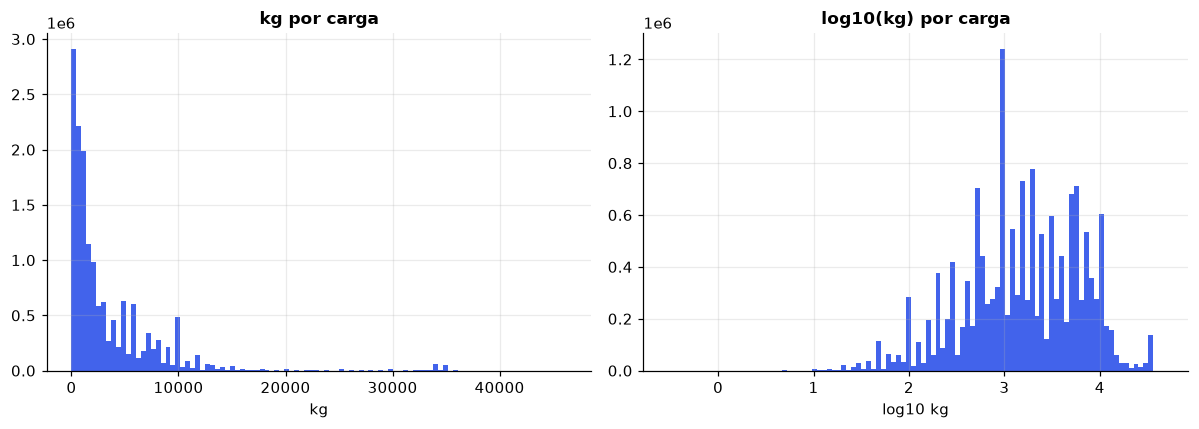

Outliers extremos (fuera de 3·IQR del log-kg dentro de cada producto): 30,272 (0.20%)
                        size     min        max
alimento                                       
Papa superior          11638  15.000    960.000
Papa parda pastusa      3596  50.000    600.000
Res en pie              2823 404.000 14,544.000
Papa sabanera           2431   5.000 35,000.000
Papa suprema            1733  50.000  1,250.000
Arveja verde en vaina    762   1.000 36,000.000
Jengibre                 740   1.000 32,000.000
Yuca                     515  25.000     63.000


In [12]:
envp = env[env["kg"] > 0]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(envp["kg"], bins=100, color="#4263eb")
axes[0].set_title("kg por carga")
axes[0].set_xlabel("kg")
axes[1].hist(np.log10(envp["kg"]), bins=100, color="#4263eb")
axes[1].set_title("log10(kg) por carga")
axes[1].set_xlabel("log10 kg")
plt.tight_layout()
plt.show()

lk = np.log(envp["kg"])
g = envp.assign(lk=lk).groupby("alimento", observed=True)["lk"]
q1, q3 = g.transform(lambda s: s.quantile(0.25)), g.transform(lambda s: s.quantile(0.75))
iqr = q3 - q1
out = (lk < q1 - 3 * iqr) | (lk > q3 + 3 * iqr)
print(f"Outliers extremos (fuera de 3·IQR del log-kg dentro de cada producto): {out.sum():,} ({out.mean():.2%})")
print(envp.loc[out, ["alimento", "kg"]].groupby("alimento", observed=True)["kg"]
      .agg(["size", "min", "max"]).sort_values("size", ascending=False).head(8))

**Interpretación.** La cantidad por carga es muy asimétrica (de 1 kg a 42 t); en escala
logarítmica se ve multimodal, con picos en tamaños estándar. Dentro de cada producto, solo 0,2 %
de las cargas queda fuera de 3·IQR del log-kg, y la mayoría son cargas pequeñas de papa (bultos
sueltos) o cargas grandes de productos que normalmente llegan en poca cantidad. Son valores
plausibles, no errores, así que no se eliminan. Como el modelo trabaja con agregados semanales
normalizados por el promedio del propio corredor (`ratio_t`), el efecto de una carga atípica se
diluye. Los outliers del panel se tratan en la sección 2.2.

### 1.7.5 Sesgos de muestreo y representatividad

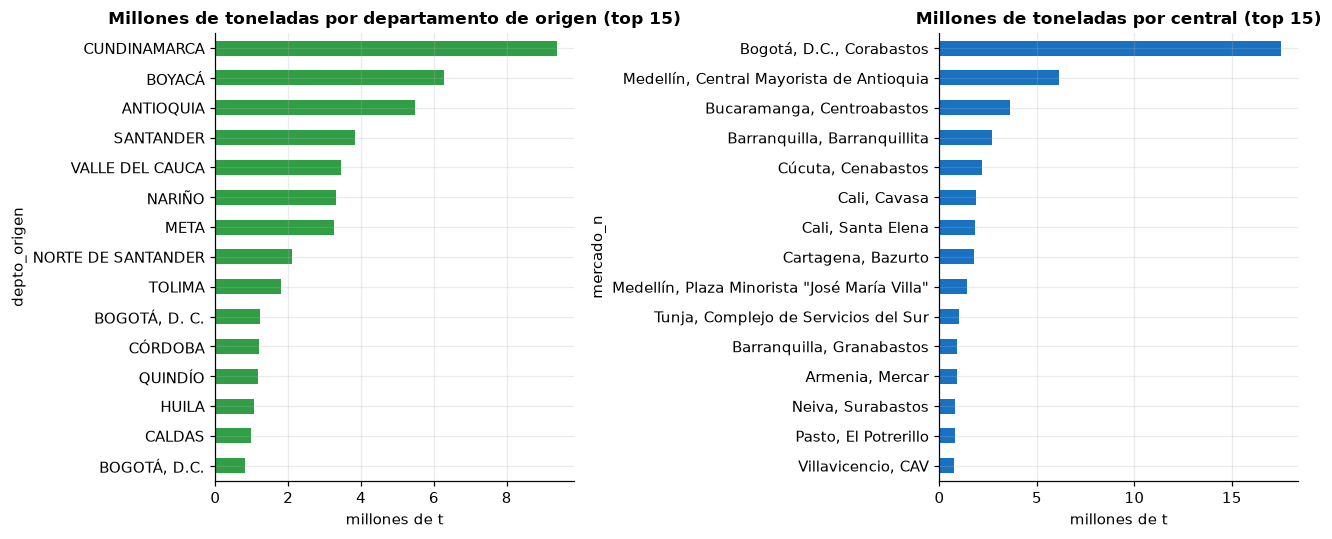

Municipios PDET oficiales: 170; aparecen como origen en SIPSA-A: 160


Participación de orígenes PDET en kg nacionales: 6.75%
Participación de Corabastos en el total: 34.84%


In [13]:
nac = env[es_nacional]
top_or = nac.groupby("depto_origen", observed=True)["kg"].sum().sort_values(ascending=False)
top_de = nac.groupby("mercado_n")["kg"].sum().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
(top_or.head(15) / 1e9).iloc[::-1].plot.barh(ax=axes[0], color="#2f9e44")
axes[0].set_title("Millones de toneladas por departamento de origen (top 15)")
axes[0].set_xlabel("millones de t")
(top_de.head(15) / 1e9).iloc[::-1].plot.barh(ax=axes[1], color="#1971c2")
axes[1].set_title("Millones de toneladas por central (top 15)")
axes[1].set_xlabel("millones de t")
plt.tight_layout()
plt.show()

pdet = pd.read_csv(u.RAW / "pdet_municipios.csv", dtype=str)
pdet_set = set(pdet["cod_muni"].str.zfill(5))
orig = nac["cod_mpio"].astype(str).unique()
print(f"Municipios PDET oficiales: {len(pdet_set)}; aparecen como origen en SIPSA-A: {len(pdet_set & set(orig))}")
print(f"Participación de orígenes PDET en kg nacionales: {nac.loc[nac['cod_mpio'].astype(str).isin(pdet_set), 'kg'].sum() / nac['kg'].sum():.2%}")
print(f"Participación de Corabastos en el total: {top_de.iloc[0] / top_de.sum():.2%}")

**Interpretación.**

* **Cobertura urbana y mayorista.** SIPSA-A mide lo que llega a 32 centrales de ciudades
  intermedias y grandes. No observa el abastecimiento de cabeceras pequeñas, mercados campesinos,
  plazas municipales ni la venta directa, que son justamente los canales más importantes en
  territorios PDET. Las conclusiones se refieren a la conexión de esos territorios con los
  grandes mercados, no a su seguridad alimentaria local.
* **Concentración.** Corabastos recibe 35 % del volumen; los departamentos andinos (Cundinamarca,
  Boyacá, Antioquia, Nariño) dominan la oferta. Un modelo ajustado por filas estará dominado por
  corredores andinos hacia Bogotá y Medellín.
* **Procedencia declarada.** El origen lo declara el transportador y puede corresponder a un
  centro de acopio y no al lugar de producción, lo que subrepresenta municipios rurales dispersos.
* **PDET.** 160 de los 170 municipios PDET aparecen alguna vez como origen, pero aportan solo
  6,8 % del volumen. Los corredores PDET serán minoría en el panel (sección 2.2).

## 1.8 Consideraciones éticas

* **Datos personales.** SIPSA-A no contiene nombres, documentos ni placas de vehículos. Los
  microdatos publicados por el DANE ya están anonimizados.
* **Riesgo de reidentificación.** La unidad mínima es el municipio de origen y el día. En
  corredores muy pequeños (un solo productor o transportador que lleva carga desde un
  municipio a una central) la serie semanal podría revelar la actividad comercial de una persona
  o empresa identificable localmente. Por eso el informe solo presenta agregados y no publica
  series de corredores individuales pequeños.
* **Coordenadas.** Se usan centroides municipales, no ubicaciones de fincas ni rutas; el
  riesgo de localizar personas es mínimo.
* **Uso de los resultados.** Un modelo que etiquete corredores PDET como "frágiles" podría
  reforzar estigmas territoriales o desviar recursos. Las predicciones deben servir para
  priorizar apoyo logístico, no para excluir territorios de mercados o inversiones.